# Линейные модели – решение

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Tuple
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs

## Задание 1. Аналитическое решение

In [2]:
df = pd.read_csv("../../production/AI_Machine_Learning.Project_3.ID_1577773/datasets/diamonds.csv")
X = df["carat"].values.reshape(-1, 1)
y = df["price"].values.reshape(-1, 1)
print(f"Размер: {X.shape[0]}, carat: {X.min():.2f}–{X.max():.2f}, price: {y.min()}–{y.max()}")

Размер: 53940, carat: 0.20–5.01, price: 326–18823


In [3]:
# Аналитическое решение МНК: w_hat = (X^T X)^{-1} X^T y
X_b = np.c_[np.ones((len(X), 1)), X]
w_analytic = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
b_v1, w_v1 = w_analytic[0, 0], w_analytic[1, 0]
print(f"Аналитическое: b = {b_v1:.2f}, w = {w_v1:.2f}")

Аналитическое: b = -2256.36, w = 7756.43


In [4]:
# Сравнение с sklearn
sk_model = LinearRegression().fit(X, y)
b_v2, w_v2 = sk_model.intercept_[0], sk_model.coef_[0, 0]
print(f"sklearn:        b = {b_v2:.2f}, w = {w_v2:.2f}")
print(f"Совпадают: {np.allclose([b_v1, w_v1], [b_v2, w_v2])}")

sklearn:        b = -2256.36, w = 7756.43
Совпадают: True


In [5]:
y_pred_analytic = X_b @ w_analytic
y_pred_sklearn = sk_model.predict(X)
print(f"MAE аналитическое: {mean_absolute_error(y, y_pred_analytic):.2f}")
print(f"MAE sklearn:       {mean_absolute_error(y, y_pred_sklearn):.2f}")

MAE аналитическое: 1007.46
MAE sklearn:       1007.46


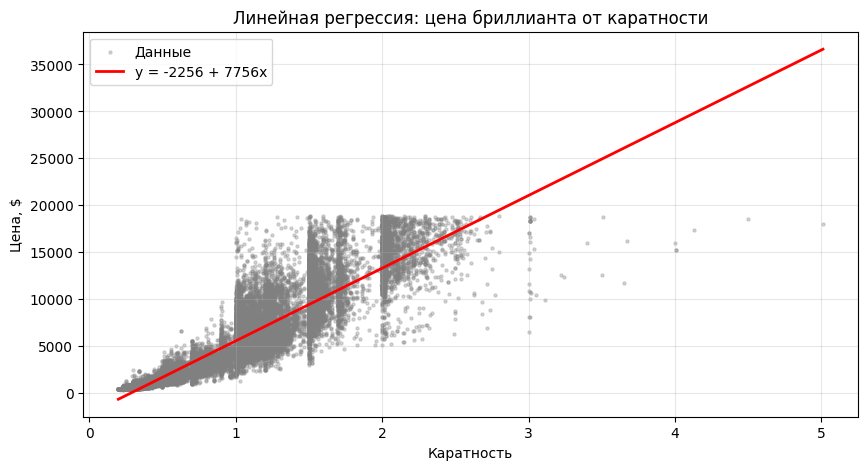

In [6]:
plt.figure(figsize=(10, 5))
plt.scatter(X, y, alpha=0.3, s=5, color="gray", label="Данные")
x_range = np.array([[X.min()], [X.max()]])
plt.plot(x_range, w_analytic[0] + w_analytic[1] * x_range, "r-", lw=2,
         label=f"y = {b_v1:.0f} + {w_v1:.0f}x")
plt.xlabel("Каратность"); plt.ylabel("Цена, $")
plt.title("Линейная регрессия: цена бриллианта от каратности")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

**Интерпретация:** w ≈ 7756 означает, что каждый дополнительный карат в среднем добавляет ~$7756 к цене.
b ≈ −2256 – формальная «стартовая цена», не имеет физического смысла (бриллиант 0 карат не существует).

## Задание 2. Градиент функции потерь

$$\frac{\partial L}{\partial b} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - b - w_1 x_i)$$

$$\frac{\partial L}{\partial w_1} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - b - w_1 x_i)\, x_i$$

## Задание 3. Обновление параметров

In [7]:
class Gradient:
    def __init__(self, X: np.ndarray, Y: np.ndarray) -> None:
        self.X = np.asarray(X)
        self.Y = np.asarray(Y).flatten()
        self.N = len(self.Y)
        self.n_features = self.X.shape[1] if self.X.ndim > 1 else 1

    def predict(self, w: np.ndarray, b: float) -> np.ndarray:
        return self.X @ w + b

    def mse(self, prediction: np.ndarray) -> float:
        return np.mean((self.Y - prediction) ** 2)

    def update(self, w: np.ndarray, b: float, a: float = 0.01) -> Tuple[np.ndarray, float]:
        errors = self.Y - self.predict(w, b)
        w_new = w - a * (-2 / self.N * (self.X.T @ errors))
        b_new = b - a * (-2 / self.N * np.sum(errors))
        return w_new, b_new

In [8]:
grad = Gradient(X, y)
w_cur, b_cur = np.zeros(X.shape[1]), 0.0

for i in range(3):
    mse_val = grad.mse(grad.predict(w_cur, b_cur))
    print(f"iter {i}: MSE = {mse_val:.0f}, w = {w_cur[0]:.2f}, b = {b_cur:.2f}")
    w_cur, b_cur = grad.update(w_cur, b_cur)

iter 0: MSE = 31382248, w = 0.00, b = 0.00
iter 1: MSE = 29837304, w = 97.62, b = 78.66
iter 2: MSE = 28395301, w = 192.30, b = 154.18


## Задание 4. Градиентный спуск

In [9]:
class GradientDescent(Gradient):
    def optimize(self, num_iterations: int, stopping_threshold: float = 0.001,
                 a: float = 0.000001, w_init: float = 0, b_init: float = 0) -> dict:
        w = np.full(self.n_features, w_init, dtype=float)
        b = float(b_init)
        history, prev_mse, decay = [], float("inf"), 0.01

        for i in range(num_iterations):
            a_t = a / (1 + decay * i)
            mse_val = self.mse(self.predict(w, b))
            history.append(mse_val)
            if i > 0 and abs(prev_mse - mse_val) < stopping_threshold:
                break
            w, b = self.update(w, b, a_t)
            prev_mse = mse_val

        return {"w": w, "b": b, "mse": self.mse(self.predict(w, b)),
                "history": history, "iterations": len(history)}

In [10]:
learning_rates = [0.0000001, 0.001, 1]
results = {}
for lr in learning_rates:
    res = GradientDescent(X, y).optimize(num_iterations=1000, stopping_threshold=0.01, a=lr)
    results[lr] = res
    print(f"LR={lr}: iters={res['iterations']}, MSE={res['mse']:.0f}, w={res['w'][0]:.2f}, b={res['b']:.2f}")

LR=1e-07: iters=1000, MSE=31378473, w=0.23, b=0.19
LR=0.001: iters=1000, MSE=12600454, w=1689.37, b=1194.77
LR=1: iters=183, MSE=2397955, w=7756.01, b=-2255.98


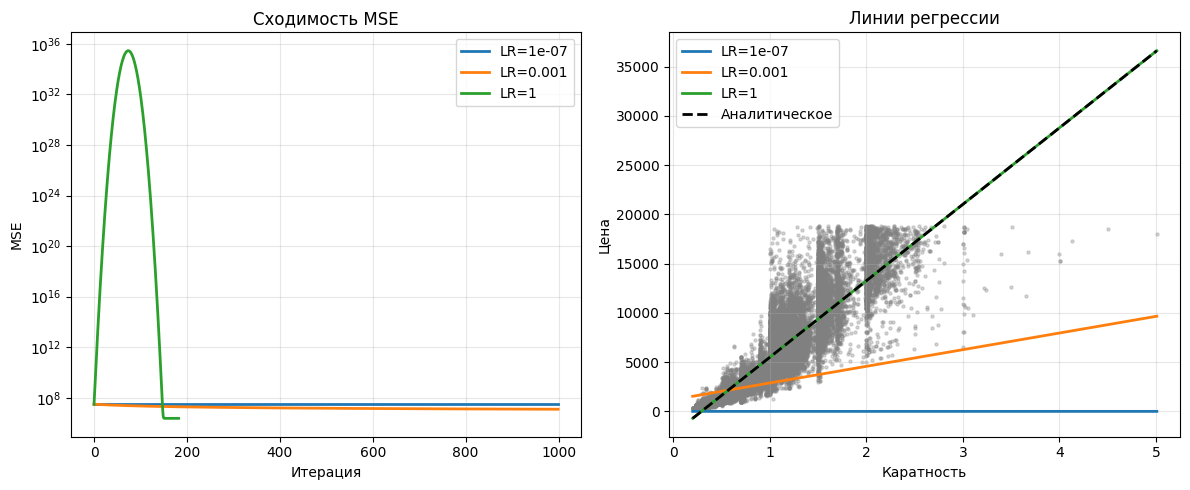

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for lr in learning_rates:
    ax1.plot(results[lr]["history"], label=f"LR={lr}", lw=2)
ax1.set(xlabel="Итерация", ylabel="MSE", title="Сходимость MSE")
ax1.set_yscale("log"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.scatter(X, y, alpha=0.3, s=5, color="gray")
x_line = np.linspace(X.min(), X.max(), 100)
for lr in learning_rates:
    ax2.plot(x_line, results[lr]["w"][0] * x_line + results[lr]["b"], label=f"LR={lr}", lw=2)
ax2.plot(x_line, w_v1 * x_line + b_v1, "k--", lw=2, label="Аналитическое")
ax2.set(xlabel="Каратность", ylabel="Цена", title="Линии регрессии")
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Задание 5. Используем все данные

In [12]:
df_full = pd.read_csv("../../production/AI_Machine_Learning.Project_3.ID_1577773/datasets/diamonds.csv")
y_full = df_full["price"]
X_full = pd.get_dummies(df_full.drop(columns=["price"]), columns=["cut", "color", "clarity"])

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=21)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [13]:
model_sgd = SGDRegressor(random_state=21).fit(X_train_sc, y_train)
y_pred_sgd = model_sgd.predict(X_test_sc)
print(f"SGDRegressor (все признаки): MAE={mean_absolute_error(y_test, y_pred_sgd):.2f}, MSE={mean_squared_error(y_test, y_pred_sgd):.2f}")

model_carat = SGDRegressor(random_state=21).fit(X_train[["carat"]], y_train)
y_pred_carat = model_carat.predict(X_test[["carat"]])
print(f"SGDRegressor (carat):        MAE={mean_absolute_error(y_test, y_pred_carat):.2f}, MSE={mean_squared_error(y_test, y_pred_carat):.2f}")

SGDRegressor (все признаки): MAE=723.22, MSE=1237948.09
SGDRegressor (carat):        MAE=1007.45, MSE=2352053.23


## Задание 6. Ridge и Lasso

In [14]:
for name, Model in [("Ridge", Ridge), ("Lasso", Lasso)]:
    m = Model(alpha=0.01).fit(X_train_sc, y_train)
    yp = m.predict(X_test_sc)
    print(f"{name:5s}: MAE={mean_absolute_error(y_test, yp):.2f}, MSE={mean_squared_error(y_test, yp):.2f}")

Ridge: MAE=730.86, MSE=1220559.04
Lasso: MAE=730.87, MSE=1220557.43


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.717e+08, tolerance: 6.910e+07
  model = cd_fast.enet_coordinate_descent(


## Задание 7. Разделяющая плоскость

In [15]:
X_blobs, y_blobs = make_blobs(n_samples=200, centers=2, n_features=2, random_state=21)
lr = LogisticRegression(penalty=None, solver="lbfgs").fit(X_blobs, y_blobs)
print(f"coef_: {lr.coef_}, intercept_: {lr.intercept_}")
print(f"accuracy: {lr.score(X_blobs, y_blobs):.4f}")

coef_: [[ 1.60563992 -0.54271774]], intercept_: [-0.01421595]
accuracy: 1.0000


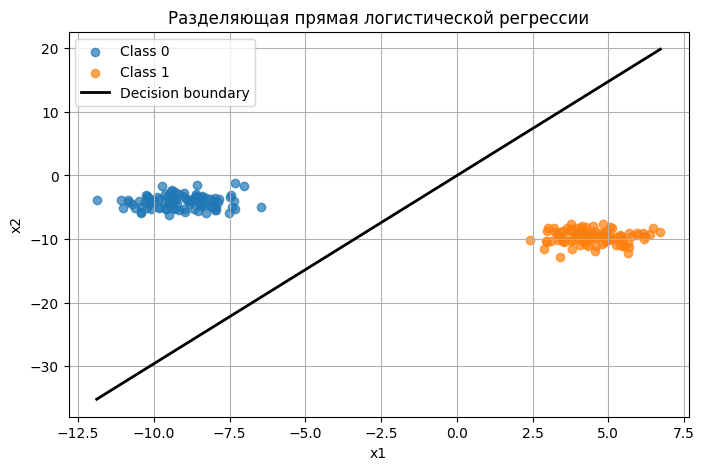

In [16]:
w1, w2 = lr.coef_[0]
b_lr = lr.intercept_[0]
x1 = np.linspace(X_blobs[:, 0].min(), X_blobs[:, 0].max(), 100)
x2 = -(w1 * x1 + b_lr) / w2

plt.figure(figsize=(8, 5))
for cls in [0, 1]:
    plt.scatter(X_blobs[y_blobs == cls, 0], X_blobs[y_blobs == cls, 1], label=f"Class {cls}", alpha=0.7)
plt.plot(x1, x2, "k-", lw=2, label="Decision boundary")
plt.xlabel("x1"); plt.ylabel("x2")
plt.title("Разделяющая прямая логистической регрессии")
plt.legend(); plt.grid(True); plt.show()

## Задание 8. Загрузка Fashion-MNIST

In [17]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets

train_fmnist = datasets.FashionMNIST(root=".", train=True, download=True)
test_fmnist = datasets.FashionMNIST(root=".", train=False, download=True)
X_train_fm, y_train_fm = train_fmnist.data.numpy(), train_fmnist.targets.numpy()
X_test_fm, y_test_fm = test_fmnist.data.numpy(), test_fmnist.targets.numpy()

class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

100%|██████████████████████████████████████████| 26.4M/26.4M [00:04<00:00, 5.43MB/s]
100%|███████████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 191kB/s]
100%|██████████████████████████████████████████| 4.42M/4.42M [00:00<00:00, 5.36MB/s]
100%|██████████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 2.59MB/s]

0: T-shirt
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot


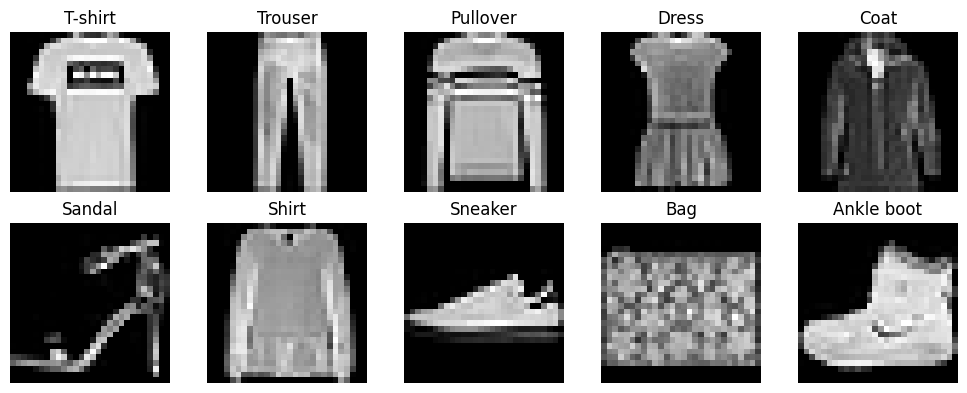

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    idx = np.where(y_train_fm == i)[0][0]
    ax.imshow(X_train_fm[idx], cmap="gray")
    ax.set_title(class_names[i]); ax.axis("off")
plt.tight_layout(); plt.show()

## Задание 9. Классификация одежды

In [19]:
X_train_flat = X_train_fm.reshape(-1, 784) / 255.0
X_test_flat = X_test_fm.reshape(-1, 784) / 255.0

lr_fm = LogisticRegression(solver="lbfgs", max_iter=500).fit(X_train_flat, y_train_fm)
print(f"Accuracy: {lr_fm.score(X_test_flat, y_test_fm):.4f}")

Accuracy: 0.8425


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
y_pred_fm = lr_fm.predict(X_test_flat)
print(confusion_matrix(y_test_fm, y_pred_fm))
print(classification_report(y_test_fm, y_pred_fm, target_names=class_names))

[[807   2  10  52   4   3 111   0  11   0]
 [  4 957   5  25   4   0   3   0   2   0]
 [ 23   4 737  10 126   0  86   1  13   0]
 [ 23  17  21 858  30   0  39   0  12   0]
 [  0   2 115  36 762   0  79   0   6   0]
 [  1   0   0   1   0 924   0  48   4  22]
 [144   2 125  40 101   0 567   0  21   0]
 [  0   0   0   0   0  36   0 935   0  29]
 [  7   1   9  14   3   5  21   6 934   0]
 [  0   1   0   0   0  13   1  41   0 944]]
              precision    recall  f1-score   support

     T-shirt       0.80      0.81      0.80      1000
     Trouser       0.97      0.96      0.96      1000
    Pullover       0.72      0.74      0.73      1000
       Dress       0.83      0.86      0.84      1000
        Coat       0.74      0.76      0.75      1000
      Sandal       0.94      0.92      0.93      1000
       Shirt       0.63      0.57      0.59      1000
     Sneaker       0.91      0.94      0.92      1000
         Bag       0.93      0.93      0.93      1000
  Ankle boot       0.95     

## Задание 10. Линейная модель на PyTorch

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_t = torch.tensor(X_train_fm.reshape(-1, 784), dtype=torch.float32) / 255.0
y_train_t = torch.tensor(y_train_fm, dtype=torch.long)
X_test_t = torch.tensor(X_test_fm.reshape(-1, 784), dtype=torch.float32) / 255.0
y_test_t = torch.tensor(y_test_fm, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=1024)


def eval_accuracy(model: nn.Module) -> float:
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            correct += (model(xb).argmax(1) == yb).sum().item()
            total += yb.numel()
    return correct / total


def train_model(model: nn.Module, epochs: int, lr: float = 0.1, opt_cls=torch.optim.SGD) -> float:
    model.to(device)
    opt = opt_cls(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            opt.step()
    return eval_accuracy(model)

In [22]:
linear_model = nn.Linear(784, 10)
acc_linear = train_model(linear_model, epochs=5)
print(f"Задание 10 – линейная модель accuracy: {acc_linear:.4f}")

Задание 10 – линейная модель accuracy: 0.8238


## Задание 11. Нейронная сеть

In [23]:
nn_model = nn.Sequential(
    nn.Linear(784, 256), nn.ReLU(),
    nn.Linear(256, 128), nn.ReLU(),
    nn.Linear(128, 10)
)
acc_nn = train_model(nn_model, epochs=10, lr=0.01, opt_cls=torch.optim.Adam)
print(f"Задание 11 – нейросеть accuracy: {acc_nn:.4f}")
print(f"Улучшение: +{(acc_nn - acc_linear) * 100:.1f}%")

Задание 11 – нейросеть accuracy: 0.8670
Улучшение: +4.3%


## Задание 12. Эксперименты

In [24]:
experiments = [
    ("3 слоя + Adam lr=0.001",
     nn.Sequential(nn.Linear(784, 512), nn.ReLU(), nn.Dropout(0.2),
                   nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.2),
                   nn.Linear(256, 10)),
     {"epochs": 15, "lr": 0.001, "opt_cls": torch.optim.Adam}),
    ("2 слоя + BatchNorm",
     nn.Sequential(nn.Linear(784, 256), nn.BatchNorm1d(256), nn.ReLU(),
                   nn.Linear(256, 10)),
     {"epochs": 10, "lr": 0.01, "opt_cls": torch.optim.Adam}),
]

for name, model, params in experiments:
    acc = train_model(model, **params)
    print(f"{name}: accuracy = {acc:.4f}")

3 слоя + Adam lr=0.001: accuracy = 0.8931
2 слоя + BatchNorm: accuracy = 0.8698


**Вывод:** добавление скрытых слоёв, Dropout и BatchNorm улучшает качество. Adam с lr=0.001 стабильно
сходится лучше, чем SGD. Основной выигрыш даёт переход от линейной модели к нейросети с 1–2 скрытыми слоями;
дальнейшее усложнение архитектуры на Fashion-MNIST даёт убывающую отдачу.